In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('winequality-red.csv')

print("Filas, columnas:", df.shape)
print("\nColumnas y tipos:")
print(df.dtypes)

print("\nDescribe (numéricas):")
print(df.describe())

print("\nDescribe (todas):")
print(df.describe(include='all'))

Filas, columnas: (1599, 12)

Columnas y tipos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Describe (numéricas):
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640

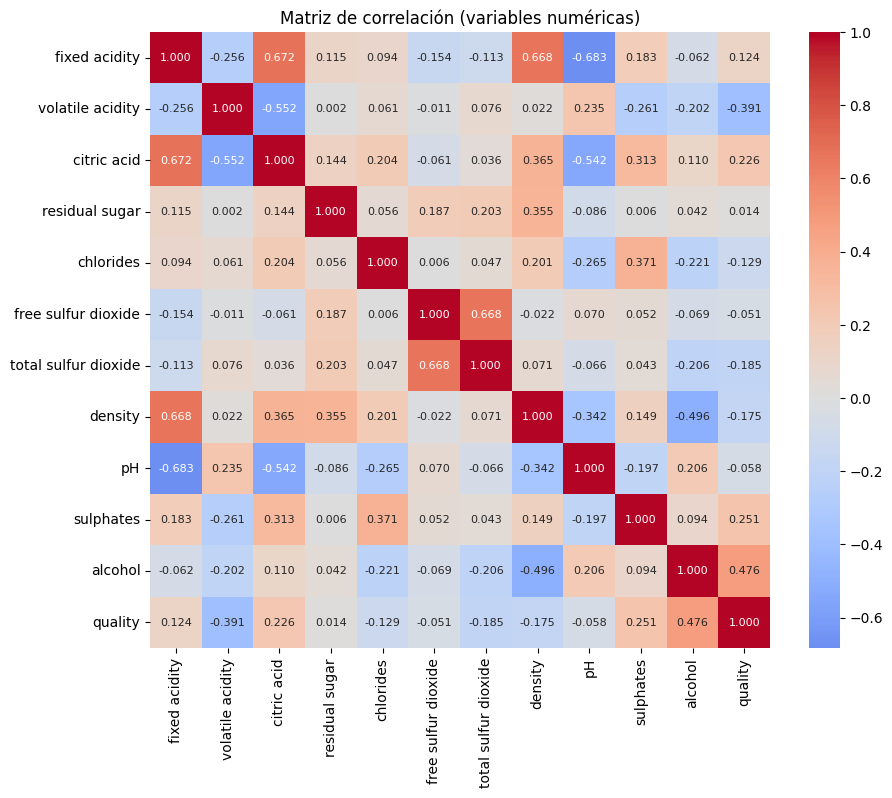

Correlación de Pearson con quality (ordenado por |r|):
alcohol                 0.476166
volatile acidity       -0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
fixed acidity           0.124052
pH                     -0.057731
free sulfur dioxide    -0.050656
residual sugar          0.013732
Name: quality, dtype: float64


In [149]:
# Matriz de correlación y mapa de calor

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, annot_kws={"size": 8})
plt.title("Matriz de correlación (variables numéricas)")
plt.show()

# Correlación de cada característica con la variable objetivo
corr_target = corr["quality"].drop("quality").sort_values(key=np.abs, ascending=False)
print("Correlación de Pearson con quality (ordenado por |r|):")
print(corr_target)

In [150]:
# Selección de un máximo de 6 características basadas en correlación

# Partimos de las variables ordenadas por |correlación con quality|
ordered_features = corr_target.index.tolist()
selected = []
max_features = 6

# Criterio simple: alta correlación con quality y no estar fuertemente correlacionadas entre sí
for feat in ordered_features:
    if len(selected) == max_features:
        break
    if not selected:
        selected.append(feat)
    else:
        too_correlated = False
        for s in selected:
            if abs(corr.loc[feat, s]) > 0.8:  # umbral de multicolinealidad
                too_correlated = True
                break
        if not too_correlated:
            selected.append(feat)

print("Características seleccionadas (<= 6):", selected)

selected_features = selected

Características seleccionadas (<= 6): ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide', 'density']


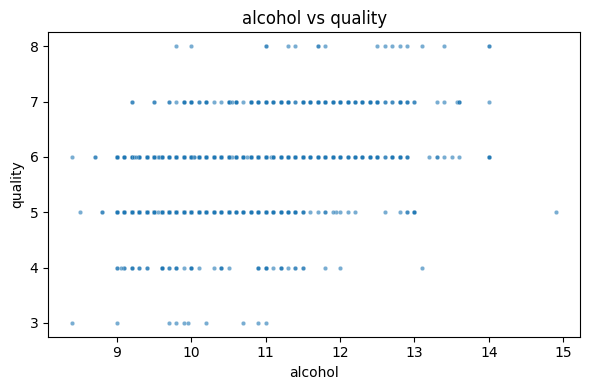

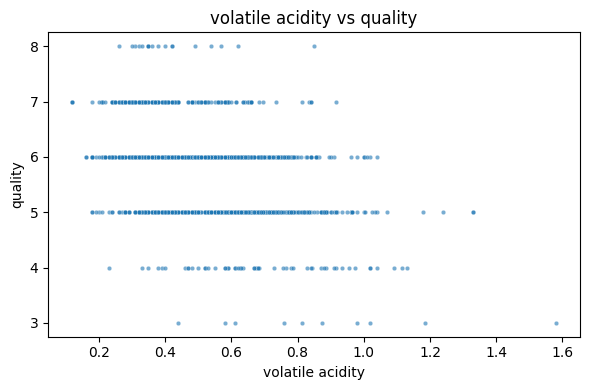

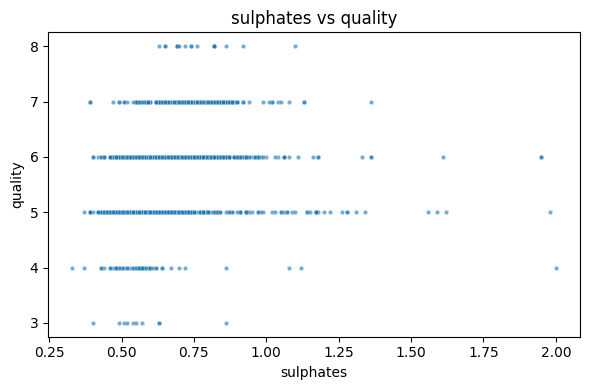

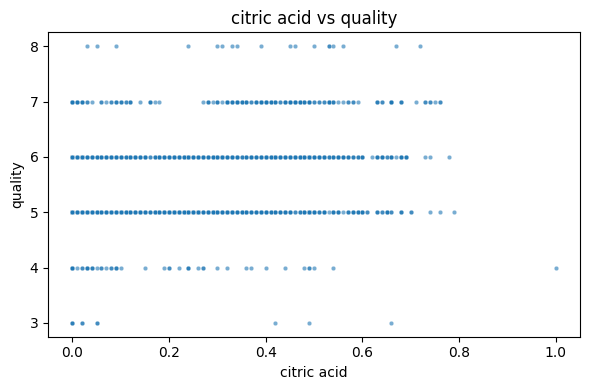

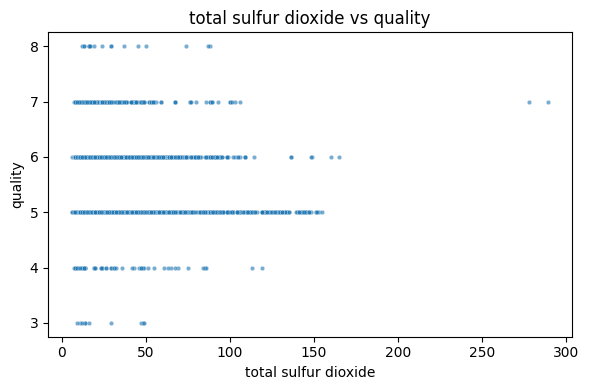

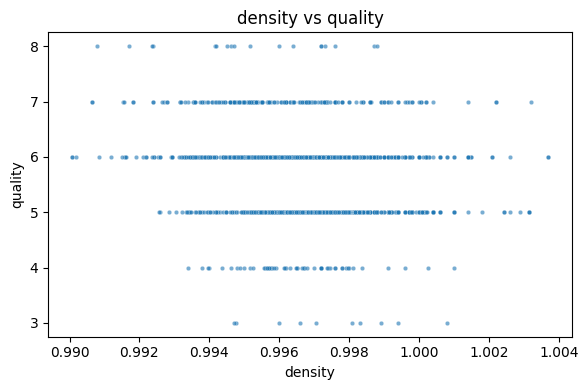

In [151]:
# Diagramas de dispersión solo para las características seleccionadas
target = "quality"
for col in selected_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df[target], s=10, alpha=0.6)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target}")
    plt.tight_layout()
    plt.show()

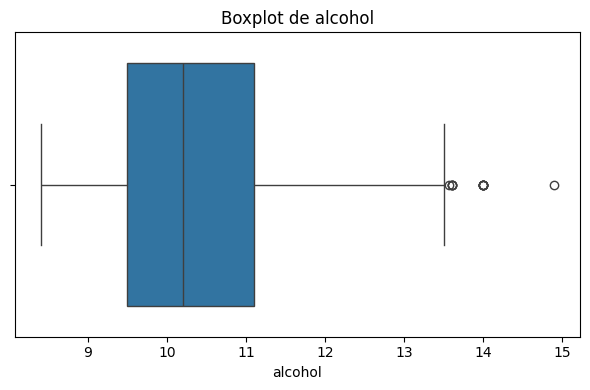

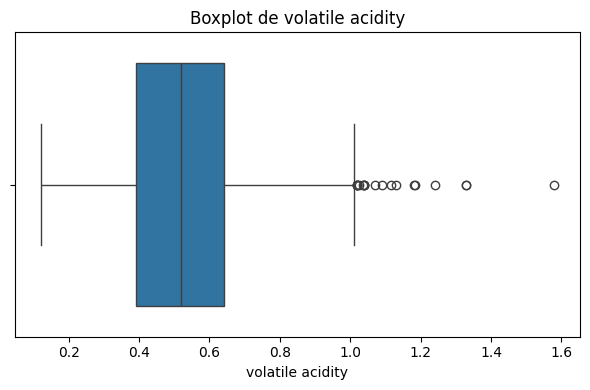

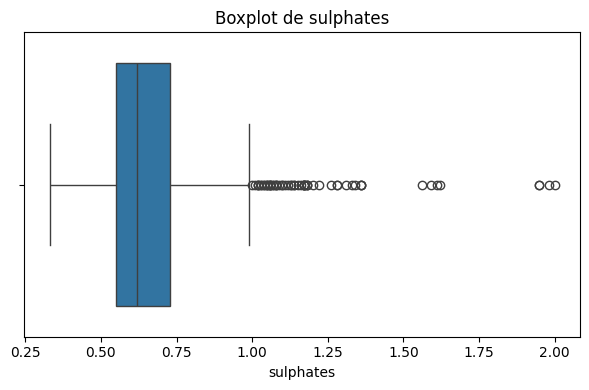

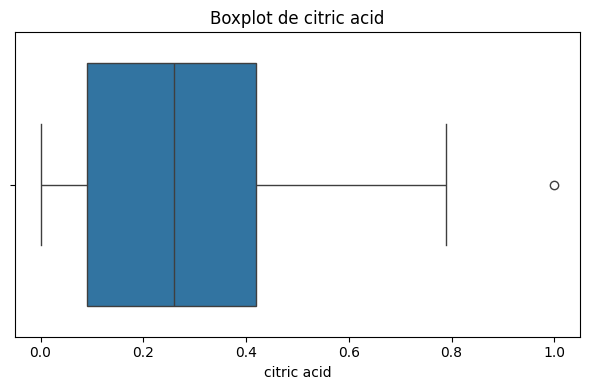

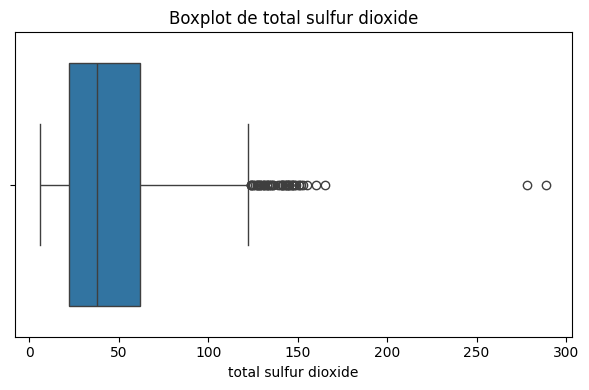

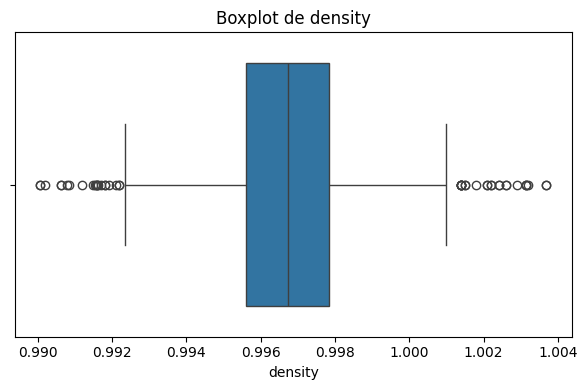

In [152]:
# Boxplots solo para las características seleccionadas (una figura por variable)
for col in selected_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

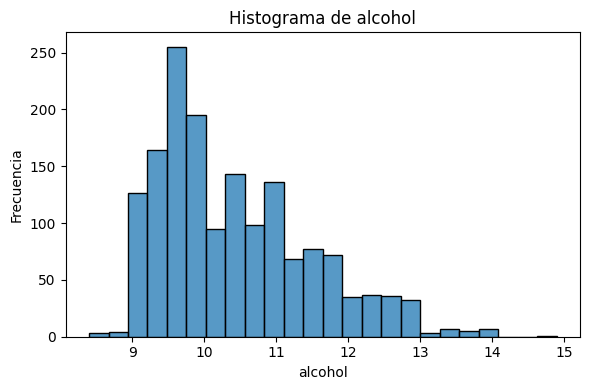

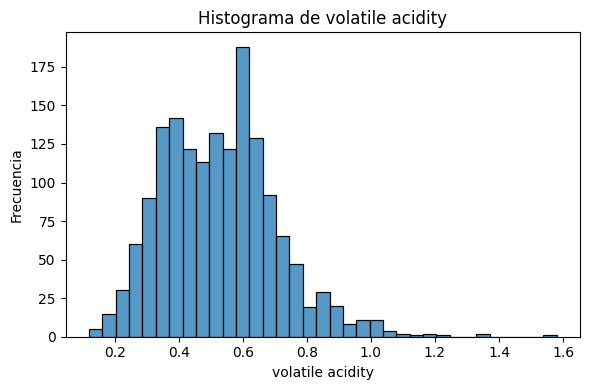

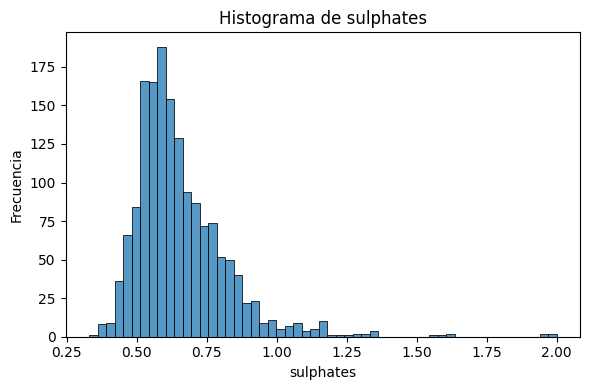

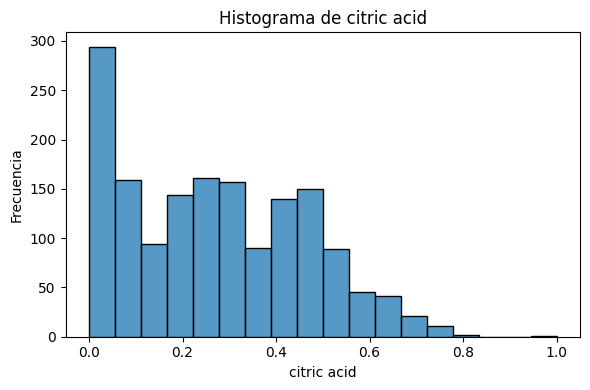

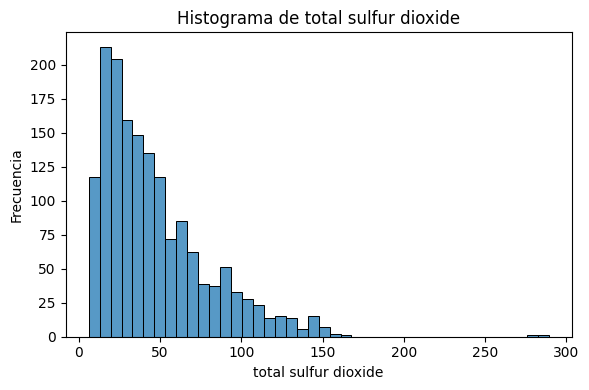

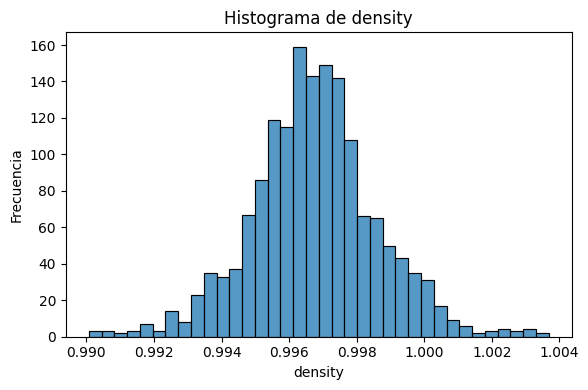

In [153]:
# Histogramas solo para las características seleccionadas (una figura por variable)
for col in selected_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=False)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

In [154]:
# Tratamiento de outliers para las características seleccionadas usando el criterio IQR
df_clean = df.copy()

for col in selected_features:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Filas antes de eliminar outliers:", len(df))
print("Filas después de eliminar outliers:", len(df_clean))

# Actualizamos df para que las siguientes celdas trabajen con el conjunto limpio
df = df_clean.reset_index(drop=True)

Filas antes de eliminar outliers: 1599
Filas después de eliminar outliers: 1416


In [155]:
# Feature engineering sobre la variable objetivo
# Creamos una versión binaria: vinos de buena calidad (>=7) vs. resto

threshold = 7

df["quality_binary"] = (df["quality"] >= threshold).astype(int)

print("Distribución de quality:")
print(df["quality"].value_counts().sort_index())
print("\nDistribución de quality_binary (0 = normal, 1 = buena calidad):")
print(df["quality_binary"].value_counts(normalize=True))

Distribución de quality:
quality
3      7
4     44
5    581
6    592
7    177
8     15
Name: count, dtype: int64

Distribución de quality_binary (0 = normal, 1 = buena calidad):
quality_binary
0    0.864407
1    0.135593
Name: proportion, dtype: float64


In [156]:
# División en entrenamiento, validación y test + preparación de datos para PyTorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Matriz de características (solo las seleccionadas) y variable objetivo binaria
X = df[selected_features].copy()
y = df["quality_binary"]  # objetivo binario para clasificación

# División estratificada 70 % train, 15 % validación, 15 % test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Tamaños:")
print("Train:", X_train.shape, "Validación:", X_val.shape, "Test:", X_test.shape)

print("\nDistribución de la clase en cada partición (proporciones):")
for name, yy in {
    "train": y_train,
    "val": y_val,
    "test": y_test,
}.items():
    print(name, ":")
    print(yy.value_counts(normalize=True))
    print("---")

# Escalado estándar usando solo información del conjunto de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Conversión a tensores de PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
y_val_t = torch.tensor(y_val.values.reshape(-1, 1), dtype=torch.float32)
y_test_t = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

input_dim = X_train_t.shape[1]
print("Dimensión de entrada:", input_dim)

Tamaños:
Train: (991, 6) Validación: (212, 6) Test: (213, 6)

Distribución de la clase en cada partición (proporciones):
train :
quality_binary
0    0.864783
1    0.135217
Name: proportion, dtype: float64
---
val :
quality_binary
0    0.863208
1    0.136792
Name: proportion, dtype: float64
---
test :
quality_binary
0    0.86385
1    0.13615
Name: proportion, dtype: float64
---
Dimensión de entrada: 6


In [157]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# Definición del modelo de Regresión Logística en PyTorch
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        # Devolvemos logits (sin sigmoide); la sigmoide se aplica en la función de pérdida
        return self.linear(x)

def train_one_run(lr, batch_size, epochs, verbose=False):
    """Entrena un modelo de regresión logística con los hiperparámetros dados
    y devuelve las métricas en validación junto con el modelo entrenado
    y el historial de pérdidas de entrenamiento y validación."""
    model = LogisticRegressionModel(input_dim)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(train_ds)

        # Pérdida en validación para esta época
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
        train_losses.append(epoch_loss)
        val_losses.append(val_loss)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - train_loss: {epoch_loss:.4f} - val_loss: {val_loss:.4f}")

    # Evaluación final en el conjunto de validación
    model.eval()
    with torch.no_grad():
        logits_val = model(X_val_t)
        probs_val = torch.sigmoid(logits_val).cpu().numpy().ravel()
    y_val_pred = (probs_val >= 0.5).astype(int)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred)
    val_rec = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_auc = roc_auc_score(y_val, probs_val)

    metrics = {
        "lr": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "val_accuracy": val_acc,
        "val_precision": val_prec,
        "val_recall": val_rec,
        "val_f1": val_f1,
        "val_auc": val_auc,
    }
    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
    }
    return model, metrics, history


=== Experimento 1 ===
Hiperparámetros: {'lr': 0.0001, 'batch_size': 32, 'epochs': 50}
Val Acc=0.830,  Prec=0.426,  Rec=0.690,  F1=0.526,  AUC=0.854

=== Experimento 2 ===
Hiperparámetros: {'lr': 0.0003, 'batch_size': 32, 'epochs': 50}
Val Acc=0.811,  Prec=0.351,  Rec=0.448,  F1=0.394,  AUC=0.784

=== Experimento 3 ===
Hiperparámetros: {'lr': 0.001, 'batch_size': 32, 'epochs': 50}
Val Acc=0.863,  Prec=0.500,  Rec=0.345,  F1=0.408,  AUC=0.880

=== Experimento 4 ===
Hiperparámetros: {'lr': 0.003, 'batch_size': 32, 'epochs': 50}
Val Acc=0.868,  Prec=0.545,  Rec=0.207,  F1=0.300,  AUC=0.882

=== Experimento 5 ===
Hiperparámetros: {'lr': 0.001, 'batch_size': 64, 'epochs': 50}
Val Acc=0.887,  Prec=0.586,  Rec=0.586,  F1=0.586,  AUC=0.878

=== Experimento 6 ===
Hiperparámetros: {'lr': 0.003, 'batch_size': 64, 'epochs': 50}
Val Acc=0.858,  Prec=0.474,  Rec=0.310,  F1=0.375,  AUC=0.880

=== Experimento 7 ===
Hiperparámetros: {'lr': 0.001, 'batch_size': 128, 'epochs': 50}
Val Acc=0.797,  Prec=0.

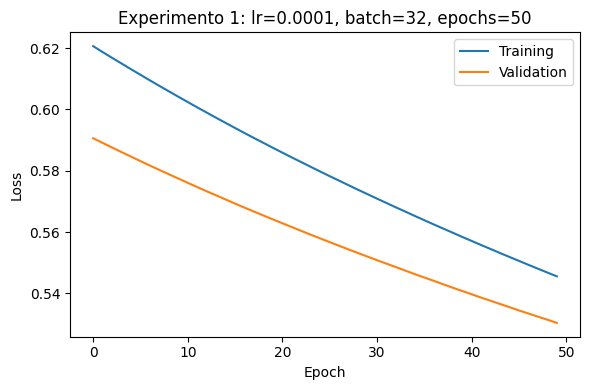

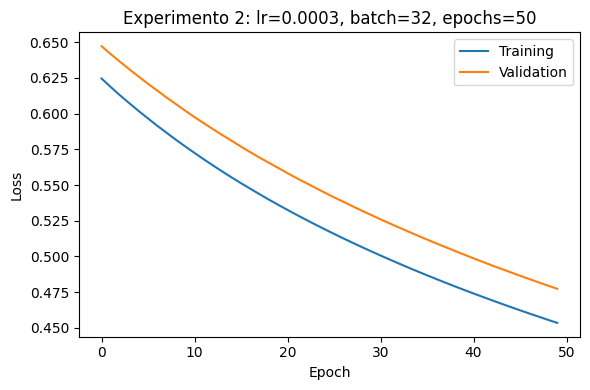

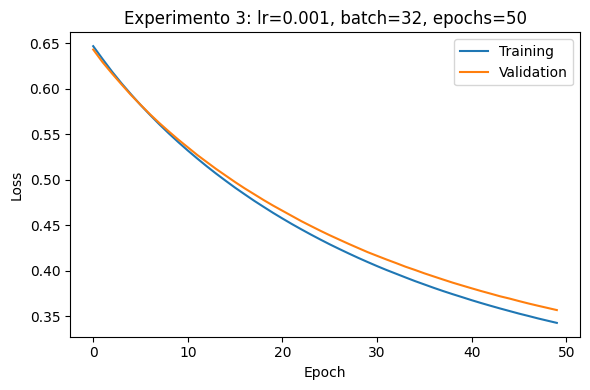

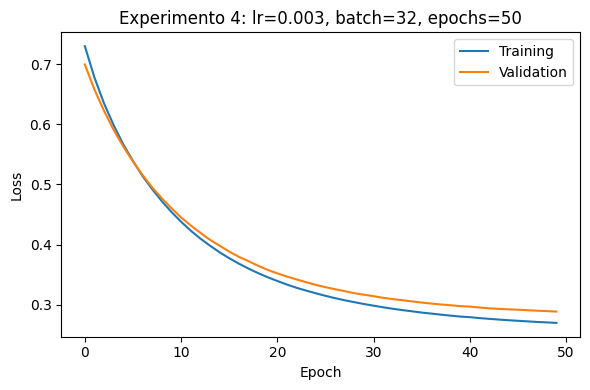

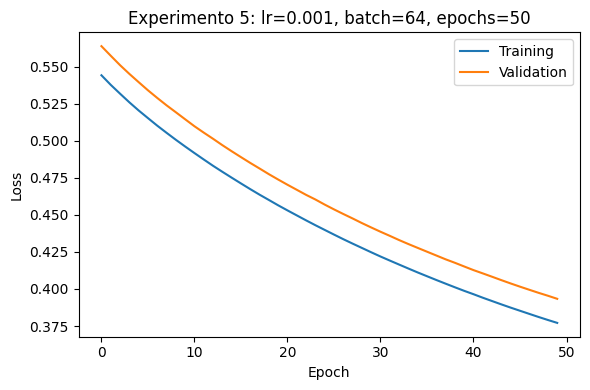

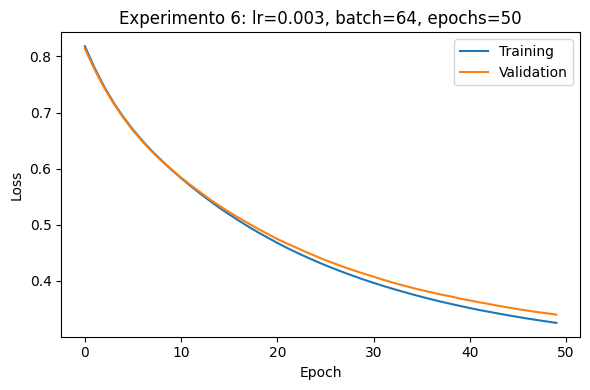

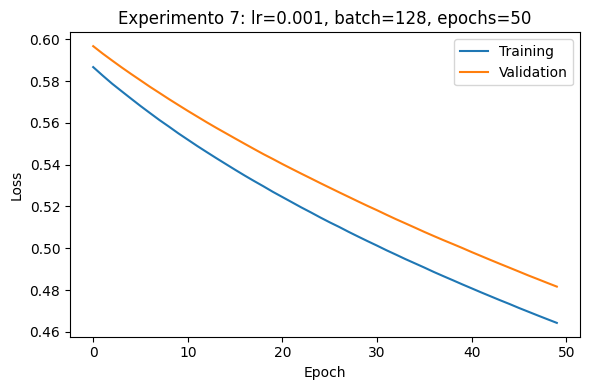

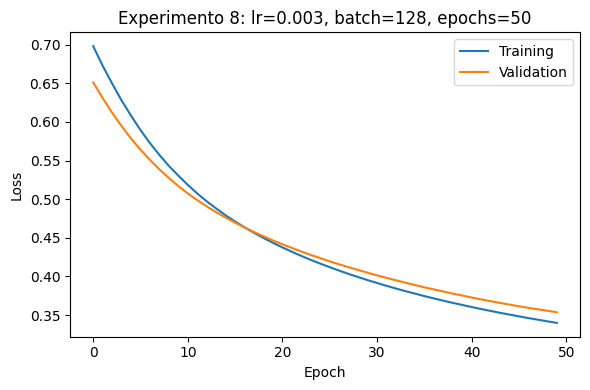

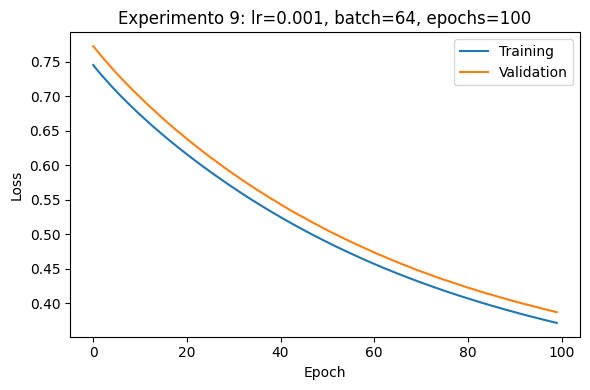

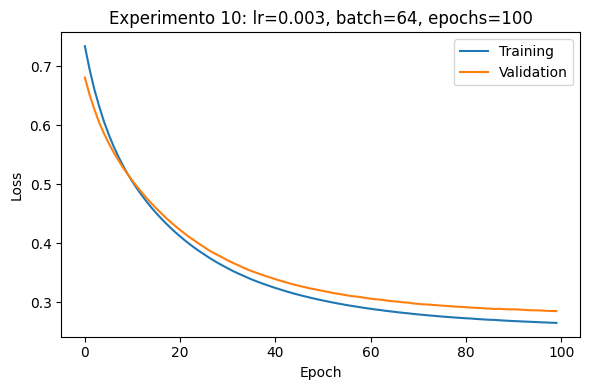


Comparación validación vs test para el mejor experimento:
Validación - Acc=0.887,  Prec=0.586,  Rec=0.586,  F1=0.586,  AUC=0.878
Test       - Acc=0.850,  Prec=0.455,  Rec=0.517,  F1=0.484,  AUC=0.804

Métricas en el conjunto de test del mejor modelo:
Accuracy:  0.850
Precisión: 0.455
Recall:    0.517
F1-score:  0.484
AUC:       0.804

Matriz de confusión (test):
[[166  18]
 [ 14  15]]


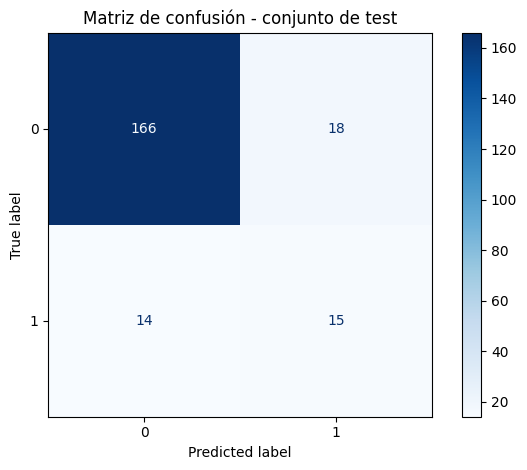

In [158]:
# Ejecución de 10 entrenamientos con distintas configuraciones de hiperparámetros
experiments = [
    {"lr": 1e-4, "batch_size": 32,  "epochs": 50},
    {"lr": 3e-4, "batch_size": 32,  "epochs": 50},
    {"lr": 1e-3, "batch_size": 32,  "epochs": 50},
    {"lr": 3e-3, "batch_size": 32,  "epochs": 50},
    {"lr": 1e-3, "batch_size": 64,  "epochs": 50},
    {"lr": 3e-3, "batch_size": 64,  "epochs": 50},
    {"lr": 1e-3, "batch_size": 128, "epochs": 50},
    {"lr": 3e-3, "batch_size": 128, "epochs": 50},
    {"lr": 1e-3, "batch_size": 64,  "epochs": 100},
    {"lr": 3e-3, "batch_size": 64,  "epochs": 100},
]

results = []
histories = []
best_model = None
best_f1 = -1.0

for i, cfg in enumerate(experiments, start=1):
    print("\n=== Experimento", i, "===")
    print("Hiperparámetros:", cfg)
    model, metrics, history = train_one_run(**cfg)
    print(
        f"Val Acc={metrics['val_accuracy']:.3f}, ",
        f"Prec={metrics['val_precision']:.3f}, ",
        f"Rec={metrics['val_recall']:.3f}, ",
        f"F1={metrics['val_f1']:.3f}, ",
        f"AUC={metrics['val_auc']:.3f}",
    )
    results.append(metrics)
    histories.append(history)
    if metrics["val_f1"] > best_f1:
        best_f1 = metrics["val_f1"]
        best_model = model

print("\nMejor experimento según F1 en validación:")
best_by_f1 = sorted(results, key=lambda m: m["val_f1"], reverse=True)[0]
print(best_by_f1)

# Tabla comparativa de métricas en validación para los 10 experimentos
import pandas as pd
results_df = pd.DataFrame(results)
print("\nTabla de métricas (validación):")
print(results_df[["lr", "batch_size", "epochs", "val_accuracy", "val_precision", "val_recall", "val_f1", "val_auc"]])

# Gráficas de pérdida (training vs validation) para cada experimento
for i, (cfg, history) in enumerate(zip(experiments, histories), start=1):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_losses"], label="Training")
    plt.plot(history["val_losses"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Experimento {i}: lr={cfg['lr']}, batch={cfg['batch_size']}, epochs={cfg['epochs']}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Evaluación del mejor modelo en el conjunto de test
best_model.eval()
with torch.no_grad():
    logits_test = best_model(X_test_t)
    probs_test = torch.sigmoid(logits_test).cpu().numpy().ravel()
y_test_pred = (probs_test >= 0.5).astype(int)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, probs_test)

print("\nComparación validación vs test para el mejor experimento:")
print(
    f"Validación - Acc={best_by_f1['val_accuracy']:.3f}, ",
    f"Prec={best_by_f1['val_precision']:.3f}, ",
    f"Rec={best_by_f1['val_recall']:.3f}, ",
    f"F1={best_by_f1['val_f1']:.3f}, ",
    f"AUC={best_by_f1['val_auc']:.3f}",
)
print(
    f"Test       - Acc={test_acc:.3f}, ",
    f"Prec={test_prec:.3f}, ",
    f"Rec={test_rec:.3f}, ",
    f"F1={test_f1:.3f}, ",
    f"AUC={test_auc:.3f}",
)

print("\nMétricas en el conjunto de test del mejor modelo:")
print(f"Accuracy:  {test_acc:.3f}")
print(f"Precisión: {test_prec:.3f}")
print(f"Recall:    {test_rec:.3f}")
print(f"F1-score:  {test_f1:.3f}")
print(f"AUC:       {test_auc:.3f}")

# Matriz de confusión en el conjunto de test
cm = confusion_matrix(y_test, y_test_pred)
print("\nMatriz de confusión (test):")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - conjunto de test")
plt.tight_layout()
plt.show()

In [160]:
# Celda auxiliar: resumen tabular de métricas para el informe (versión compacta)

import pandas as pd

import json



# Redondeamos métricas de validación y las mostramos en pantalla

val_cols = ["lr", "batch_size", "epochs", "val_accuracy", "val_precision", "val_recall", "val_f1", "val_auc"]

results_df_rounded = results_df[val_cols].round(3)

print("=== Tabla de métricas de validación (redondeada) ===")

print(results_df_rounded)



# Construimos un resumen con el mejor experimento y las métricas de test

best_summary = {

    "best_by_f1": {

        "lr": best_by_f1["lr"],

        "batch_size": int(best_by_f1["batch_size"]),

        "epochs": int(best_by_f1["epochs"]),

        "val_accuracy": float(best_by_f1["val_accuracy"]),

        "val_precision": float(best_by_f1["val_precision"]),

        "val_recall": float(best_by_f1["val_recall"]),

        "val_f1": float(best_by_f1["val_f1"]),

        "val_auc": float(best_by_f1["val_auc"]),

    },

    "test_metrics": {

        "accuracy": float(test_acc),

        "precision": float(test_prec),

        "recall": float(test_rec),

        "f1": float(test_f1),

        "auc": float(test_auc),

    },

}



print("\n=== Resumen mejor experimento (validación) y métricas de test ===")

print(json.dumps(best_summary, indent=2))


=== Tabla de métricas de validación (redondeada) ===
      lr  batch_size  epochs  val_accuracy  val_precision  val_recall  val_f1  \
0  0.000          32      50         0.830          0.426       0.690   0.526   
1  0.000          32      50         0.811          0.351       0.448   0.394   
2  0.001          32      50         0.863          0.500       0.345   0.408   
3  0.003          32      50         0.868          0.545       0.207   0.300   
4  0.001          64      50         0.887          0.586       0.586   0.586   
5  0.003          64      50         0.858          0.474       0.310   0.375   
6  0.001         128      50         0.797          0.370       0.690   0.482   
7  0.003         128      50         0.873          0.562       0.310   0.400   
8  0.001          64     100         0.882          0.567       0.586   0.576   
9  0.003          64     100         0.868          0.545       0.207   0.300   

   val_auc  
0    0.854  
1    0.784  
2    0.880  
3  